In [1]:
import bayesflow as bf
import jax.numpy as jnp
import keras
import matplotlib.pyplot as plt
import numpy as np

from jax.scipy import stats

from approximator import LikelihoodApproximator
from priors import truncated_normal_rvs
from rdmc import rdmc_experiment_simple, rdmc_prior_single, rdmc_single_accumulator
from density import rdmc_approx_likelihood, get_pdf

INFO:2025-12-12 17:21:21,883:jax._src.xla_bridge:822: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'


In [2]:
def simulator_fun(**kwargs):
    return rdmc_single_accumulator(**kwargs, t_max=5000, a_shape=2)


def meta(batch_size):
    num_obs = 500 # np.random.default_rng(2025).integers(250, 750)

    return dict(num_obs=num_obs)

simulator = bf.simulators.make_simulator([rdmc_prior_single, simulator_fun], meta_fn=meta)

In [3]:
param_names = ["v_c", "tau", "amp", "s", "b", "t0"]

test_data = simulator.sample(1)
# test_data["x"][..., 0] *= 1000
prior_draws = np.array([test_data[p] for p in param_names]).squeeze()

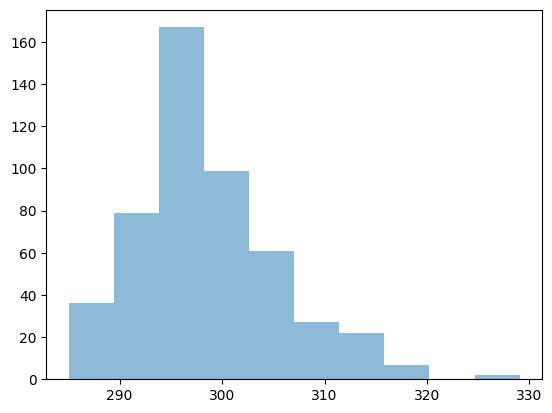

In [4]:
rt = test_data["x"]

fig, ax = plt.subplots()

ax.hist(rt[0], alpha = 0.5)

plt.show()

In [5]:
approximator = keras.saving.load_model("outputs/rdmc_single/flow_matching/epochs=20/mlp_depth=3/mlp_residual=true/mlp_width=5/checkpoints/model.keras")
# approximator.inference_network.integrate_kwargs["steps"] = 100
# approximator.inference_network.integrate_kwargs["method"] = "rk45"

In [6]:
ll_approximator = LikelihoodApproximator(approximator)

log_pdf, log_sf = ll_approximator.log_pdf_sf(test_data)

E1212 17:21:26.433467  179484 cuda_blas.cc:196] failed to create cublas handle: the resource allocation failed
E1212 17:21:26.433502  179484 cuda_blas.cc:199] Failure to initialize cublas may be due to OOM (cublas needs some free memory when you initialize it, and your deep-learning framework may have preallocated more than its fair share), or may be because this binary was not built with support for the GPU in your machine.


XlaRuntimeError: Exception encountered when calling FlowMatching.call().

[1mINTERNAL: Failed to initialize BLAS support[0m

Arguments received by FlowMatching.call():
  • xz=jnp.ndarray(shape=(1, 500, 1), dtype=float32)
  • conditions=jnp.ndarray(shape=(1, 500, 6), dtype=float32)
  • inverse=False
  • density=True
  • training=False
  • kwargs=<class 'inspect._empty'>

In [ ]:
def approx_pdf(data, t_max=1500.0, dt=5.0):
    # 1. Adjust RT
    rt = data["x"][0]
    decision_time = rt - data["t0"][0]
    
    params = dict(
        mu_c=data["v_c"][0],
        A=data["amp"][0],
        alpha=2.0, tau=data["tau"][0], 
        b=data["b"][0], sigma=data["s"][0]
    )

    # 2. Get PDFs for both accumulators
    t_grid, pdf1 = get_pdf(params, t_max, dt)
    
    # 3. Compute CDFs (Cumulative Sum * dt)
    
    # 4. Find index corresponding to decision time
    # We use soft interpolation or nearest index. For simplicity, nearest:
    idx = jnp.round(decision_time / dt).astype(int) - 1
    
    # Safety clipping for indices
    idx = jnp.clip(idx, 0, len(t_grid)-1)

    # Likelihood if choice == 0
    dens = pdf1[idx]
    
    # Avoid log(0)
    return jnp.log(jnp.maximum(dens, 1e-10))

In [ ]:
log_pdf_approx = approx_pdf(test_data)

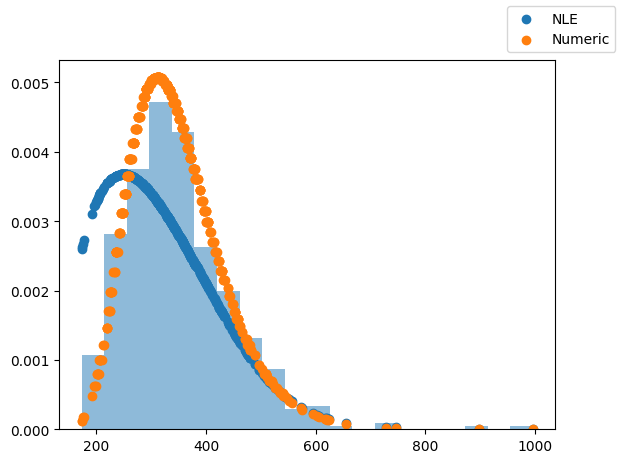

In [ ]:
fig, ax = plt.subplots()
ax.hist(rt[0], bins=20, density=True, alpha=0.5)
ax.scatter(rt, np.exp(log_pdf), label="NLE")
ax.scatter(rt, np.exp(log_pdf_approx), label="Numeric")

fig.legend()

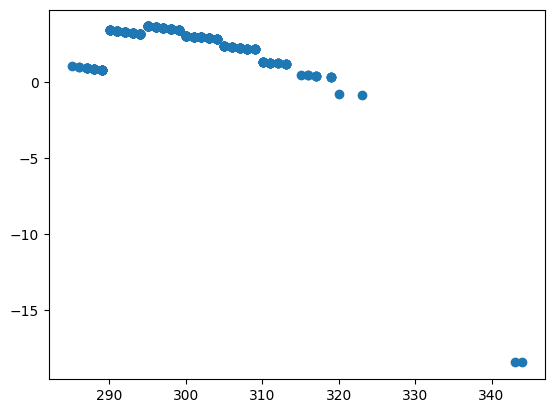

In [10]:
plt.scatter(rt, log_pdf_approx - log_pdf)